In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
dataset_path = "/kaggle/input/traffic-violation-dataset-for-two-wheeler/TwoWheelerDataset"
images_path = os.path.join(dataset_path, "Images")
labels_path = os.path.join(dataset_path, "Labels")

In [3]:
images_files = sorted(os.listdir(images_path))

In [4]:
image_arrays = []

In [5]:
for file in images_files:
    img_path = os.path.join(images_path, file)
    img = mpimg.imread(img_path)  
    image_arrays.append(img)
    print(f"{file}: Original Shape {img.shape}") 

0024473_203A_jpg.rf.1f3653348e5f220d3e820fc5284d2039.jpg: Original Shape (3380, 3564, 3)
00268e63-Bairidevar_Koppa_1073_3_3_2023_10_36_51_jpg.rf.a5d32acb2be98f08109b909a13648296.jpg: Original Shape (640, 640, 3)
006a5072-Bagalkot_Petrol_Pump_2656_1_16_2023_13_36_17_jpg.rf.d53b3ee97aeaa9eccd26f31238941566.jpg: Original Shape (640, 640, 3)
00c5c93a-Bairidevar_Koppa_1073_3_7_2023_18_21_17_jpg.rf.0e7970f3e601df7a7ec890b355b08931.jpg: Original Shape (640, 640, 3)
00eea11a-Railway_Under_Bridge__Gadag_Road__1669_11_16_2022_15_04_01_jpg.rf.bf67f341064e9a9ac2cb0d6774c4c761.jpg: Original Shape (640, 640, 3)
0140f02f-tmc_upload_8_20231031173221_jpeg.rf.503ce20da7fb0160ef9cc668267b3b9f.jpg: Original Shape (640, 640, 3)
015fea64-Railway_Under_Bridge__Gadag_Road__1669_11_16_2022_13_40_17_jpg.rf.3d6f0b9874697f6c37926bd62b345fb2.jpg: Original Shape (640, 640, 3)
019e8db5-TMC_3282021_14809_PM_192-168-0-101_CAM_4_main_20210324115520_jpg.rf.f9f11bcc58160419ae3e80a8d2dfdc35.jpg: Original Shape (640, 640, 

In [6]:
print(len(images_files))

2675


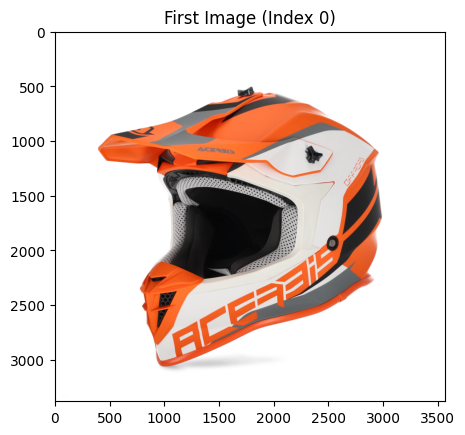

In [7]:
plt.imshow(image_arrays[0])
plt.title("First Image (Index 0)")
plt.show()

In [8]:
resized_images = []
oob_files = []

In [9]:
target_size = (640, 640)

In [10]:
output_labels_path = "/kaggle/working/Updated_Labels"  
os.makedirs(output_labels_path, exist_ok=True)

In [11]:
for i, img in enumerate(image_arrays):
    orig_h, orig_w = img.shape[:2]  
    resized_img = cv2.resize(img, target_size) 
    resized_images.append(resized_img)
    print(f"Image {i} resized to {resized_img.shape}")  


    label_path = os.path.join(labels_path, images_files[i].replace(".jpg", ".txt"))
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        updated_annotations = []
        has_oob = False  

        for line in lines:
            parts = line.strip().split()
            class_id = parts[0]
            x_center = float(parts[1])
            y_center = float(parts[2])
            bbox_width = float(parts[3])
            bbox_height = float(parts[4])

          
            if not (0 <= x_center <= 1 and 0 <= y_center <= 1 and 0 <= bbox_width <= 1 and 0 <= bbox_height <= 1):
                has_oob = True

 
            x_center = x_center * orig_w / target_size[0]
            y_center = y_center * orig_h / target_size[1]
            bbox_width = bbox_width * orig_w / target_size[0]
            bbox_height = bbox_height * orig_h / target_size[1]

            updated_annotations.append(f"{class_id} {x_center:.6f} {y_center:.6f} {bbox_width:.6f} {bbox_height:.6f}")

        if has_oob:
            oob_files.append(label_path)  # Store files with OOB coordinates
            print(f"⚠ Warning: Out-of-bounds coordinates found in {label_path}")

        updated_label_path = os.path.join(output_labels_path, images_files[i].replace(".jpg", ".txt"))
        with open(updated_label_path, "w") as f:
            f.write("\n".join(updated_annotations))



print("Resizing completed and YOLO annotations updated successfully!")

Image 0 resized to (640, 640, 3)
Image 1 resized to (640, 640, 3)
Image 2 resized to (640, 640, 3)
Image 3 resized to (640, 640, 3)
Image 4 resized to (640, 640, 3)
Image 5 resized to (640, 640, 3)
Image 6 resized to (640, 640, 3)
Image 7 resized to (640, 640, 3)
Image 8 resized to (640, 640, 3)
Image 9 resized to (640, 640, 3)
Image 10 resized to (640, 640, 3)
Image 11 resized to (640, 640, 3)
Image 12 resized to (640, 640, 3)
Image 13 resized to (640, 640, 3)
Image 14 resized to (640, 640, 3)
Image 15 resized to (640, 640, 3)
Image 16 resized to (640, 640, 3)
Image 17 resized to (640, 640, 3)
Image 18 resized to (640, 640, 3)
Image 19 resized to (640, 640, 3)
Image 20 resized to (640, 640, 3)
Image 21 resized to (640, 640, 3)
Image 22 resized to (640, 640, 3)
Image 23 resized to (640, 640, 3)
Image 24 resized to (640, 640, 3)
Image 25 resized to (640, 640, 3)
Image 26 resized to (640, 640, 3)
Image 27 resized to (640, 640, 3)
Image 28 resized to (640, 640, 3)
Image 29 resized to (640

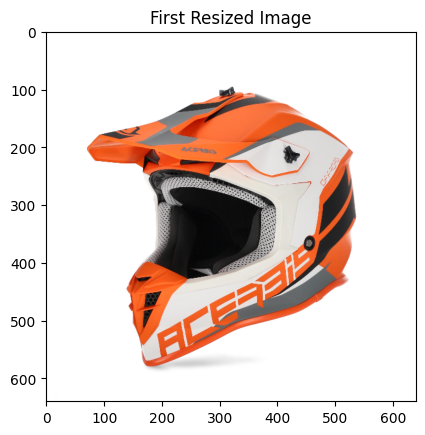

In [12]:
plt.imshow(resized_images[0])
plt.title("First Resized Image")
plt.show()

In [13]:
if oob_files:
    print("Out-of-Bounds Annotations Found in:")
    for file in oob_files:
        print(f"- {file}")
else:
    print("No out-of-bounds annotations found.")

No out-of-bounds annotations found.


In [14]:
import shutil
import yaml

In [15]:
split_base = "/kaggle/working/YOLO_Split"
train_img_dir = os.path.join(split_base, "train", "images")
val_img_dir = os.path.join(split_base, "val", "images")
test_img_dir = os.path.join(split_base, "test", "images")
train_lbl_dir = os.path.join(split_base, "train", "labels")
val_lbl_dir = os.path.join(split_base, "val", "labels")
test_lbl_dir = os.path.join(split_base, "test", "labels")

In [16]:
for folder in [train_img_dir, val_img_dir, test_img_dir, train_lbl_dir, val_lbl_dir, test_lbl_dir]:
    os.makedirs(folder, exist_ok=True)

In [17]:
image_files = sorted([f for f in os.listdir(images_path) if f.endswith(".jpg")])

In [18]:
print(len(image_files))

2675


In [19]:
train_files, temp_files = train_test_split(image_files, test_size=0.2, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

In [20]:
def move_files(file_list, img_dest, lbl_dest):
    for file in file_list:
        img_src = os.path.join(images_path, file)
        lbl_src = os.path.join(labels_path, file.replace(".jpg", ".txt"))

        shutil.copy(img_src, os.path.join(img_dest, file))
        if os.path.exists(lbl_src):  #
            shutil.copy(lbl_src, os.path.join(lbl_dest, file.replace(".jpg", ".txt")))

In [21]:
move_files(train_files, train_img_dir, train_lbl_dir)
move_files(val_files, val_img_dir, val_lbl_dir)
move_files(test_files, test_img_dir, test_lbl_dir)

In [22]:
data_yaml = {
    "train": os.path.join(split_base, "train"),
    "val": os.path.join(split_base, "val"),
    "test": os.path.join(split_base, "test"),
    "nc": 6,  
    "names": ["bike", "numberplate", "triple_riding", "using_mobile", "without_helmet", "with_helmet"]  
}

In [23]:
yaml_path = os.path.join(split_base, "data.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

In [24]:
print(f" data.yaml saved at: {yaml_path}")

 data.yaml saved at: /kaggle/working/YOLO_Split/data.yaml


In [25]:
print(f" Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

 Train: 2140, Val: 267, Test: 268


In [26]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.0/950.0 kB 17.7 MB/s eta 0:00:00


In [27]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [28]:
model = YOLO("yolo12m.pt") 

100%|██████████| 39.0M/39.0M [00:00<00:00, 197MB/s]


In [29]:
model.train(
    data="/kaggle/working/YOLO_Split/data.yaml",  
    epochs=45, 
    imgsz=640,  
    batch=4,  
    device="cuda", 
    workers=2,  
    amp=True,  
    cache=False  
)

Ultralytics 8.3.98 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo12m.pt, data=/kaggle/working/YOLO_Split/data.yaml, epochs=45, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=2, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, s

100%|██████████| 755k/755k [00:00<00:00, 17.5MB/s]


Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 4]        
  7                  -1  1   2360320  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 66.6MB/s]


AMP: checks passed ✅


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 34/34 [00:05<00:00,  6.13it/s]


                   all        267        614      0.836      0.807      0.873      0.598
                  bike        123        136      0.905      0.909      0.956      0.825
           numberplate        126        168      0.907      0.868      0.928        0.6
         triple_riding         77         77      0.788      0.918      0.956      0.643
          using_mobile         38         38      0.656      0.447      0.565      0.211
        without_helmet         95        121      0.905      0.784      0.886      0.625
           with_helmet         61         74      0.854      0.919      0.948      0.683


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.2ms preprocess, 15.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9f544da4d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [30]:
trained_model_path = "/kaggle/working/runs/detect/train/weights/best.pt"
destination_path = "/kaggle/working/best_model.pt"


shutil.move(trained_model_path, destination_path)

print(" Model saved successfully at:", destination_path)

 Model saved successfully at: /kaggle/working/best_model.pt


In [31]:
model = YOLO("/kaggle/working/best_model.pt")  

In [32]:
metrics = model.val(data="/kaggle/working/YOLO_Split/data.yaml")


Ultralytics 8.3.98 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12m summary (fused): 169 layers, 20,109,538 parameters, 0 gradients, 67.1 GFLOPs


val: Scanning /kaggle/working/YOLO_Split/val/labels.cache... 267 images, 0 backgrounds, 0 corrupt: 100%|██████████| 267/267 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:10<00:00,  1.55it/s]


                   all        267        614      0.834      0.806      0.873      0.599
                  bike        123        136      0.905       0.91      0.956      0.829
           numberplate        126        168      0.907      0.867      0.926      0.595
         triple_riding         77         77      0.782      0.909      0.956      0.642
          using_mobile         38         38      0.658      0.447      0.565      0.214
        without_helmet         95        121      0.896      0.784      0.884      0.625
           with_helmet         61         74      0.854      0.919      0.949      0.687


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 1.2ms preprocess, 35.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val


In [33]:
print(metrics)

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9f43107a00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [34]:
import pandas as pd

In [35]:
results_dict = {
    "mAP_50": [metrics.box.map50],  
    "mAP_50-95": [metrics.box.map],  
    "Precision": [metrics.box.p],  
    "Recall": [metrics.box.r]  
}

In [36]:
results_df = pd.DataFrame(results_dict)

In [37]:
print(results_df)

     mAP_50  mAP_50-95                                          Precision  \
0  0.872705   0.598605  [0.904922751812926, 0.9066800603571892, 0.7816...   

                                              Recall  
0  [0.9097967826801114, 0.8674914106353941, 0.909...  


In [38]:
accuracy = metrics.box.map50 * 100 
print(f"Model Accuracy (mAP@50): {accuracy:.2f}%")

Model Accuracy (mAP@50): 87.27%


In [39]:
model = YOLO("best_model.pt")

In [40]:
test_image_path = "/kaggle/input/test-images/Test_Images/test1.jpg"

In [41]:
test_image = cv2.imread(test_image_path)

In [42]:
results = model(test_image)


0: 640x480 1 bike, 1 numberplate, 1 with_helmet, 52.9ms
Speed: 2.5ms preprocess, 52.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 480)


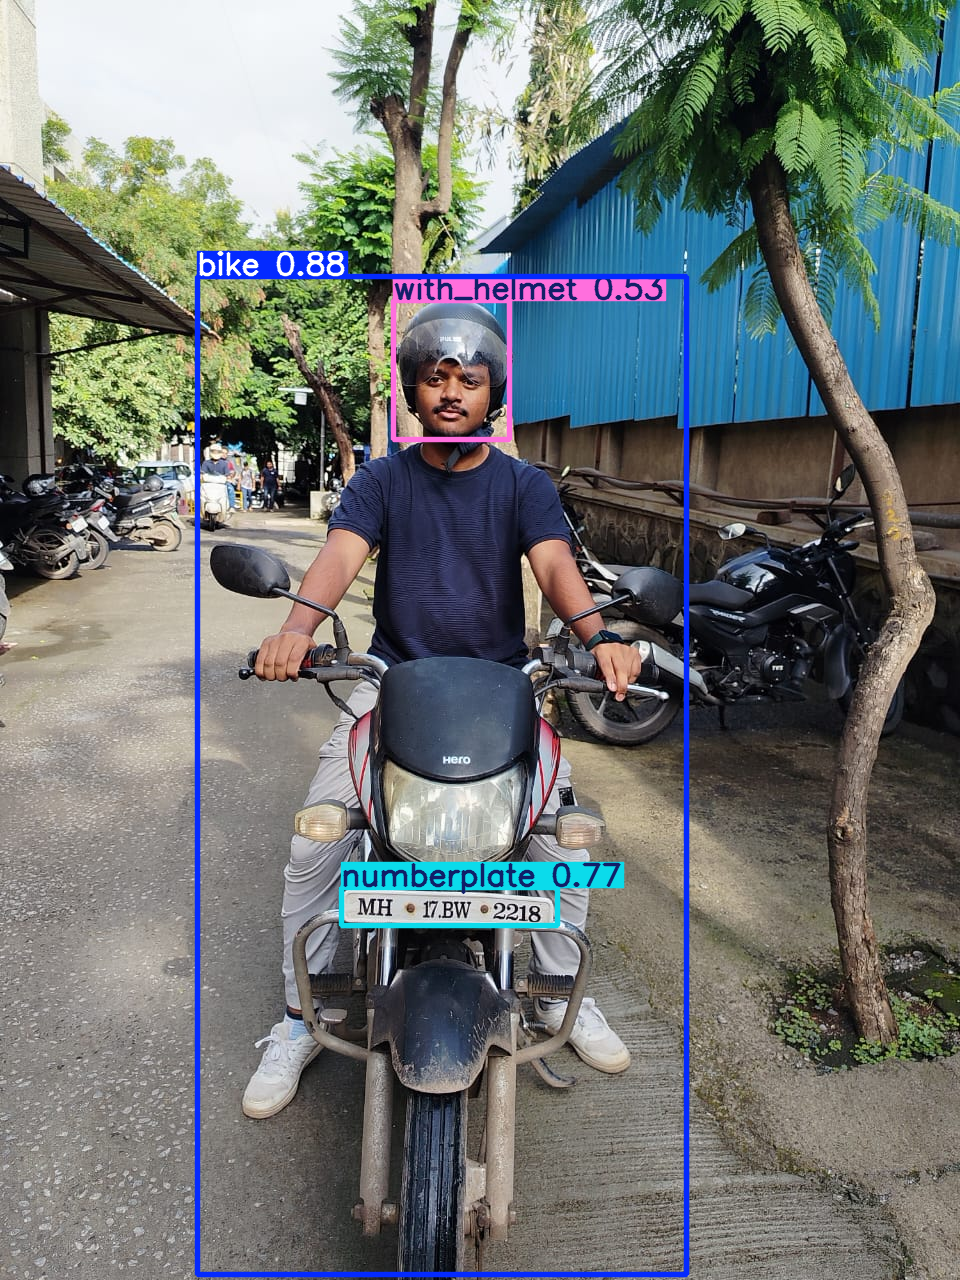

In [43]:
for r in results:
    r.show()

In [44]:
for result in results:
    for box in result.boxes:
        class_id = int(box.cls)
        confidence = box.conf.item()
        print(f"Detected: {result.names[class_id]}, Confidence: {confidence:.2f}")

Detected: bike, Confidence: 0.88
Detected: numberplate, Confidence: 0.77
Detected: with_helmet, Confidence: 0.53
